### Business Problem Statement

Airbnb operates in a highly heterogeneous marketplace where pricing behavior, room-type availability, and neighborhood-level supply vary significantly across locations. In a complex urban environment such as New York City, understanding these variations is critical for identifying high-demand areas, optimizing listing strategies, and improving platform-level supply balance.

This project investigates how Airbnb listings are distributed across NYC boroughs, how pricing differs geographically, which room types dominate inventory, and how minimum stay policies shape rental behavior. The goal is to uncover structural patterns within the marketplace that explain supply concentration and pricing dynamics.

Through exploratory data analysis, this project provides a data-driven overview of the NYC Airbnb ecosystem and highlights key spatial and pricing trends influencing short-term rental supply.

### Imports and settings

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format

### Load data

In [80]:
data_frame = pd.read_csv(r'D:\Data\projects\Capstone-EDA-project-Airbnb-bookings-analysis-main_2\dataset\Airbnb NYC 2019.csv')

In [81]:
data = data_frame.copy()

In [82]:
data.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [84]:
data.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

### Data cleaning 

In [85]:
data['id'].fillna('unknown',inplace=True)
data['host_name'].fillna('no_name',inplace=True)
data['id'] = data['id'].astype('object')
data['host_id'] = data['host_id'].astype('object')

In [86]:
data.duplicated().sum()

0

In [87]:
data.nunique()

id                                48895
name                              47905
host_id                           37457
host_name                         11453
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

In [88]:
data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,"48,895.00","48,895.00","48,895.00","48,895.00","48,895.00","38,843.00","48,895.00","48,895.00"
mean,40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,40.91,-73.71,"10,000.00","1,250.00",629.00,58.50,327.00,365.00


In [89]:
data.describe(include = 'object')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48895,48879,48895,48895,48895,48895,48895,38843
unique,48895,47905,37457,11453,5,221,3,1764
top,2539,Hillside Hotel,219517861,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,1,18,327,417,21661,3920,25409,1413


<Axes: xlabel='price'>

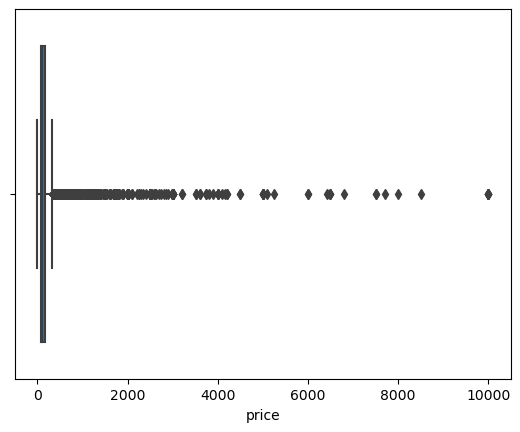

In [90]:
sns.boxplot(
    data = data , 
    x = data['price']
)

In [91]:
q0_price_quantial = data['price'].quantile(q=0.05)
q1_price_quantial = data['price'].quantile(q=0.95)
data['price'] = data['price'].clip( lower = q0_price_quantial, upper = q1_price_quantial)

<Axes: xlabel='price'>

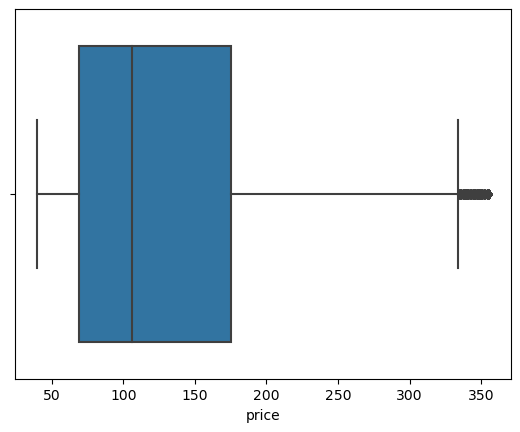

In [92]:
sns.boxplot(
    data = data , 
    x = data['price']
)

<Axes: xlabel='minimum_nights'>

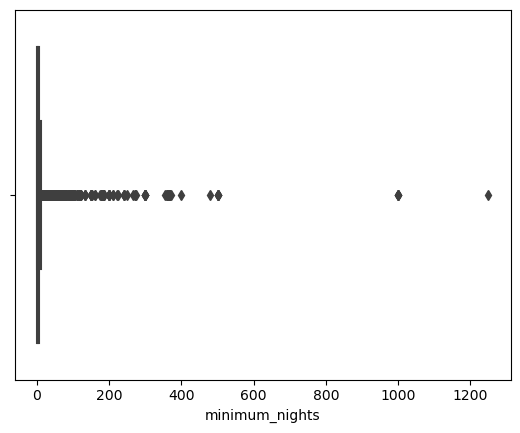

In [93]:
sns.boxplot(
    data = data , 
    x = data['minimum_nights']
)

In [94]:
q0_night_quantial = data['minimum_nights'].quantile(q=0.05)
q1_night_quantial = data['minimum_nights'].quantile(q=0.99)
data['minimum_nights'] = data['minimum_nights'].clip(  upper = q1_night_quantial)

<Axes: xlabel='minimum_nights'>

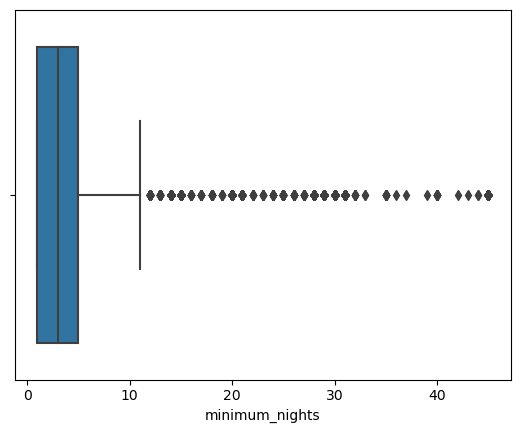

In [95]:
sns.boxplot(
    data = data , 
    x = data['minimum_nights']
)

### EDA / Analysis sections

Q1 --How are Airbnb listings distributed across different price ranges in NYC?

In [96]:
price_distribution = data['price']

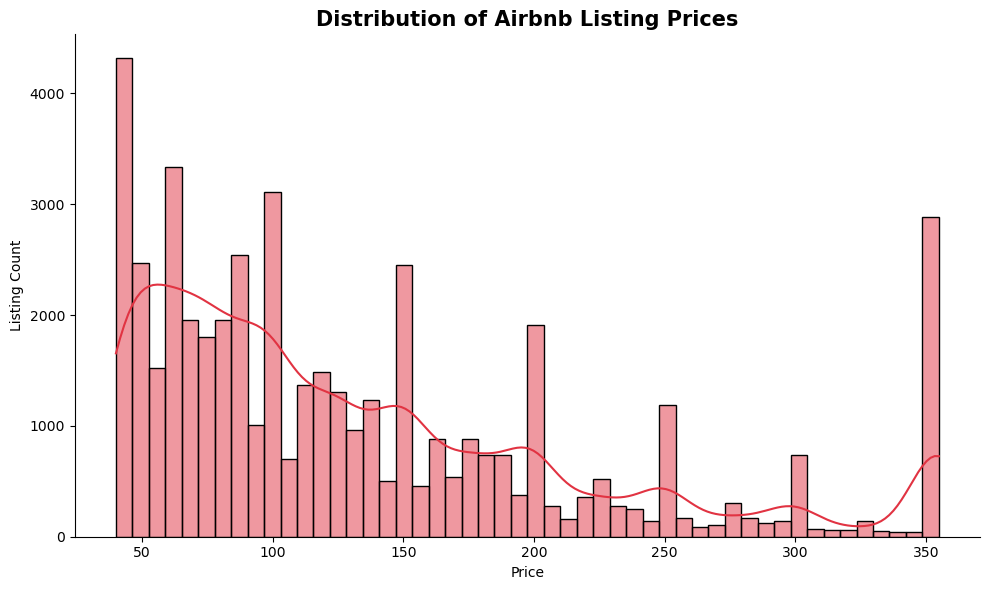

In [97]:
plt.figure(figsize=(10,6))

sns.histplot(
    price_distribution,
    bins=50,
    kde=True,
    color=sns.color_palette("rocket")[3]
)

plt.title("Distribution of Airbnb Listing Prices", fontsize=15, weight="bold")
plt.xlabel("Price")
plt.ylabel("Listing Count")

sns.despine()
plt.tight_layout()
plt.show()

The majority of rental prices fall within the $50–$150 range. Notably, there is a visible spike in the number of listings at the $250 price point, and another smaller peak at $350. Overall, most rentals are priced below $200. Additionally, we observe a decrease in the number of properties as prices increase

Q2 --Which neighborhood groups dominate the Airbnb supply across NYC?

In [98]:
listings_per_group = (
    data
    .groupby('neighbourhood_group')['id']
    .count()
    .sort_values(ascending=False)
)

listings_per_group

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: id, dtype: int64

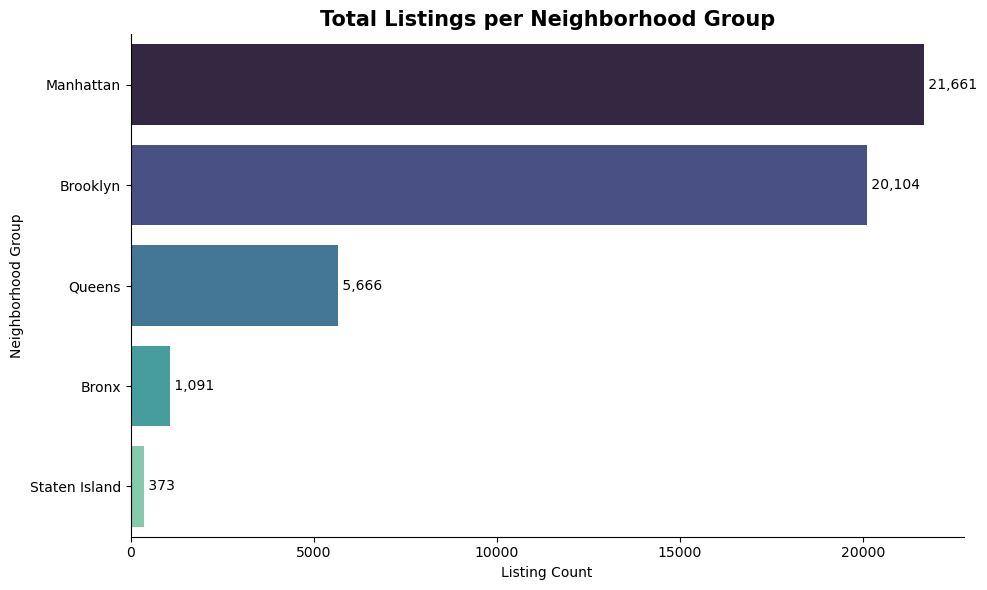

In [99]:
plt.figure(figsize=(10,6))

colors = sns.color_palette("mako", len(listings_per_group))

sns.barplot(
    y=listings_per_group.index,
    x=listings_per_group.values,
    palette=colors
)

plt.title("Total Listings per Neighborhood Group", fontsize=15, weight="bold")
plt.xlabel("Listing Count")
plt.ylabel("Neighborhood Group")

for i, v in enumerate(listings_per_group.values):
    plt.text(v, i, f" {v:,}", va='center')

sns.despine()
plt.tight_layout()
plt.show()

Manhattan and Brooklyn dominate the housing market, each with around 20,000 properties, a clear lead over Queens, which has approximately 6,000. The Bronx and Staten Island have very few properties in comparison

Q3 --How does average listing price vary across NYC neighborhood groups?

In [100]:
avg_price_group = (
    data
    .groupby('neighbourhood_group')['price']
    .mean()
    #.sort_values(ascending=False)
)

avg_price_group

neighbourhood_group
Bronx            83.88
Brooklyn        114.59
Manhattan       166.73
Queens           94.15
Staten Island    96.01
Name: price, dtype: float64

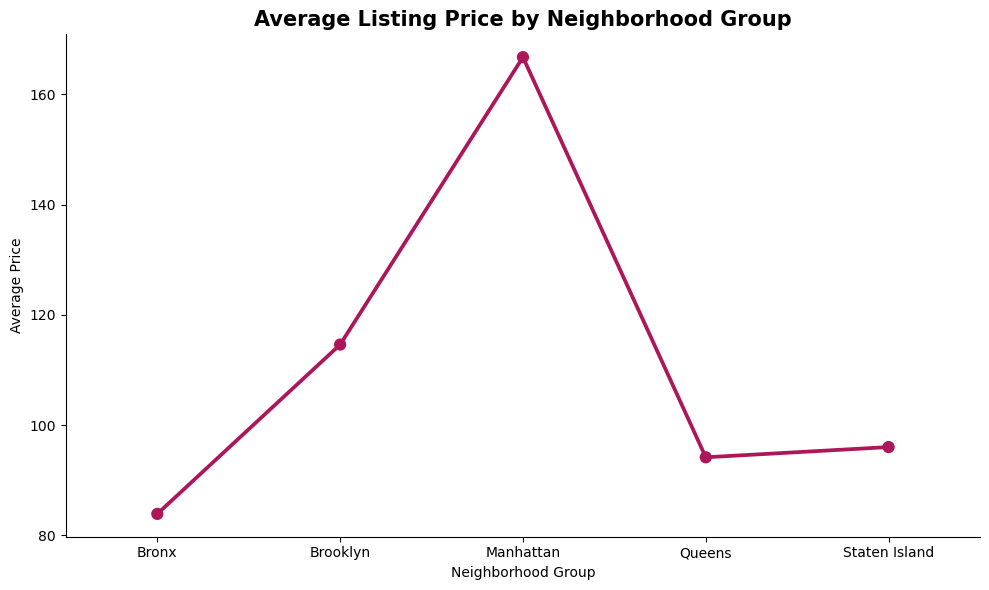

In [101]:
plt.figure(figsize=(10,6))

sns.pointplot(
    x=avg_price_group.index,
    y=avg_price_group.values,
    color=sns.color_palette("rocket")[2]
)

plt.title("Average Listing Price by Neighborhood Group", fontsize=15, weight="bold")
plt.xlabel("Neighborhood Group")
plt.ylabel("Average Price")

sns.despine()
plt.tight_layout()
plt.show()

Manhattan has the highest average price, with a clear lead over Brooklyn in second place. Queens and Staten Island show similar moderate price, while the Bronx has the lowest.

Q4 --How does price variability differ between neighborhood groups?

In [102]:
price_by_group = data[['neighbourhood_group','price']]

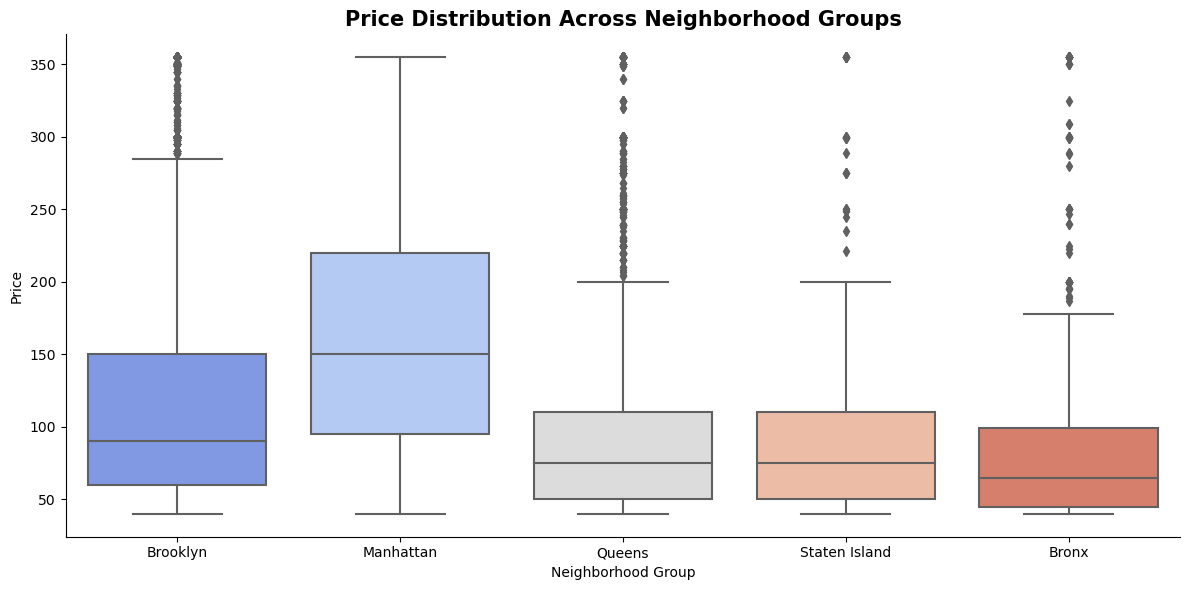

In [103]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=price_by_group,
    x='neighbourhood_group',
    y='price',
    palette="coolwarm"
)

plt.title("Price Distribution Across Neighborhood Groups", fontsize=15, weight="bold")
plt.xlabel("Neighborhood Group")
plt.ylabel("Price")

sns.despine()
plt.tight_layout()
plt.show()

Although Manhattan has the highest number of Airbnb listings and is the city’s core, its prices are relatively stable compared to other boroughs. In contrast, other boroughs show greater variation in Airbnb prices, with some listings significantly above or below the average.

Q5 --Which neighborhoods host the highest number of Airbnb listings?

In [104]:
top_neighbourhoods = (
    data
    .groupby(['neighbourhood_group' , 'neighbourhood'] , as_index = False)['id']
    .count()
    .sort_values(by = 'id' ,ascending=False)
    .head(10)
)

top_neighbourhoods

,neighbourhood_group,neighbourhood,id
93,Brooklyn,Williamsburg,3920
50,Brooklyn,Bedford-Stuyvesant,3714
105,Manhattan,Harlem,2658
58,Brooklyn,Bushwick,2465
124,Manhattan,Upper West Side,1971
106,Manhattan,Hell's Kitchen,1958
100,Manhattan,East Village,1853
123,Manhattan,Upper East Side,1798
65,Brooklyn,Crown Heights,1564
112,Manhattan,Midtown,1545


In [105]:
top_neighbourhoods = (
    data
    .groupby('neighbourhood')['id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_neighbourhoods

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: id, dtype: int64

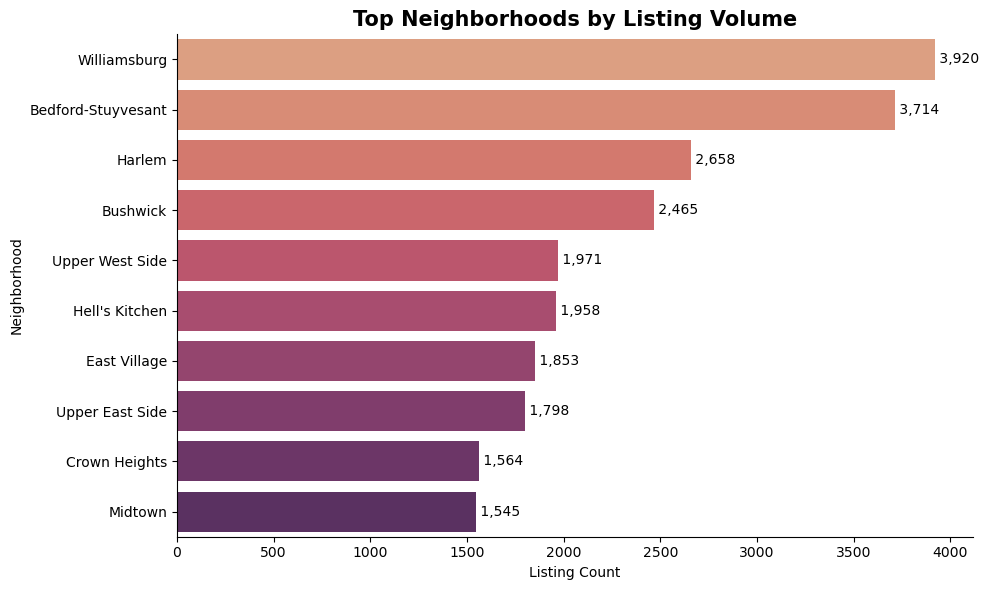

In [106]:
plt.figure(figsize=(10,6))

colors = sns.color_palette("flare", len(top_neighbourhoods))

sns.barplot(
    y=top_neighbourhoods.index,
    x=top_neighbourhoods.values,
    palette=colors
)

plt.title("Top Neighborhoods by Listing Volume", fontsize=15, weight="bold")
plt.xlabel("Listing Count")
plt.ylabel("Neighborhood")

for i, v in enumerate(top_neighbourhoods.values):
    plt.text(v, i, f" {v:,}", va='center')

sns.despine()
plt.tight_layout()
plt.show()

The top 10 neighborhoods with the highest number of apartments are all located in Brooklyn and Manhattan

Q6 --Top 10 Lowest Prices by Neighborhood Group

In [107]:
top10_min_price = (
    data
    .sort_values(by='price', ascending=True)
    [['neighbourhood_group','neighbourhood','price']]
    .head(10)
)

top10_min_price

,neighbourhood_group,neighbourhood,price
4663,Brooklyn,Crown Heights,40
41176,Queens,Sunnyside,40
31379,Brooklyn,Midwood,40
14914,Brooklyn,Bedford-Stuyvesant,40
41179,Manhattan,Harlem,40
2034,Brooklyn,Flatbush,40
41182,Queens,Jamaica,40
25486,Queens,Long Island City,40
14902,Brooklyn,Borough Park,40
4141,Brooklyn,Williamsburg,40


Q7 --Top 10 Highest Prices by Neighborhood Group

In [108]:
top10_max_price = (
    data
    .sort_values(by='price', ascending=False)
    [['neighbourhood_group','neighbourhood','price']]
    .head(10)
)

top10_max_price

,neighbourhood_group,neighbourhood,price
46137,Manhattan,Murray Hill,355
47533,Manhattan,Kips Bay,355
10520,Brooklyn,Clinton Hill,355
43318,Manhattan,Greenwich Village,355
30965,Manhattan,Midtown,355
43317,Manhattan,Greenwich Village,355
24101,Brooklyn,Fort Greene,355
45967,Manhattan,Greenwich Village,355
43316,Manhattan,Financial District,355
7430,Manhattan,Tribeca,355


Q8 --hat is the distribution of Airbnb inventory across room types?

In [109]:
room_type_counts = data['room_type'].value_counts()

room_type_counts

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

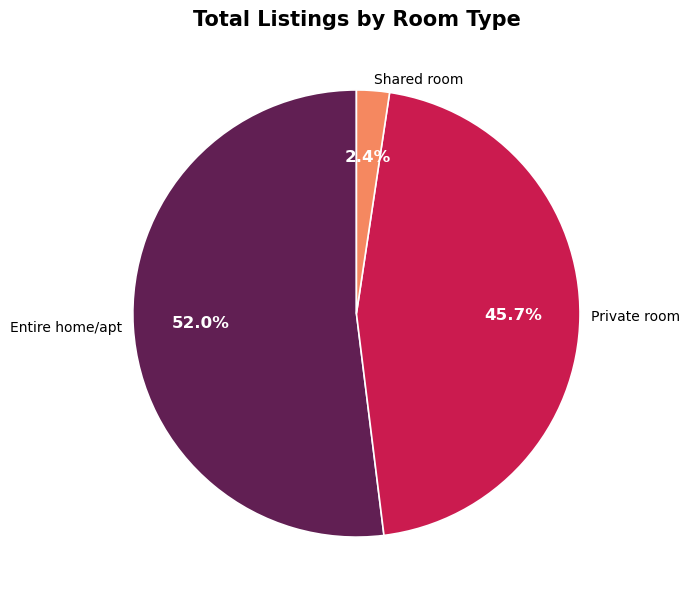

In [110]:
plt.figure(figsize=(7,7))

colors = sns.color_palette("rocket", len(room_type_counts))

wedges, texts, autotexts = plt.pie(
    room_type_counts.values,
    labels=room_type_counts.index,
    autopct=lambda p: f'{p:.1f}%',
    startangle=90,
    colors=colors,
    pctdistance=0.7,
    labeldistance=1.05,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)

plt.setp(autotexts, color='white', weight='bold', fontsize=12)

plt.title("Total Listings by Room Type", fontsize=15, weight="bold")

plt.tight_layout()
plt.show()

The majority of listings are for entire homes. Private rooms come next but with a smaller share, while shared rooms are almost nonexistent.

Q9 --What minimum stay requirements characterize most Airbnb listings?

In [111]:
minimum_nights_distribution = data['minimum_nights']
minimum_nights_distribution.value_counts().head(10)


minimum_nights
1     12720
2     11696
3      7999
30     3760
4      3303
5      3034
7      2058
6       752
14      562
45      501
Name: count, dtype: int64

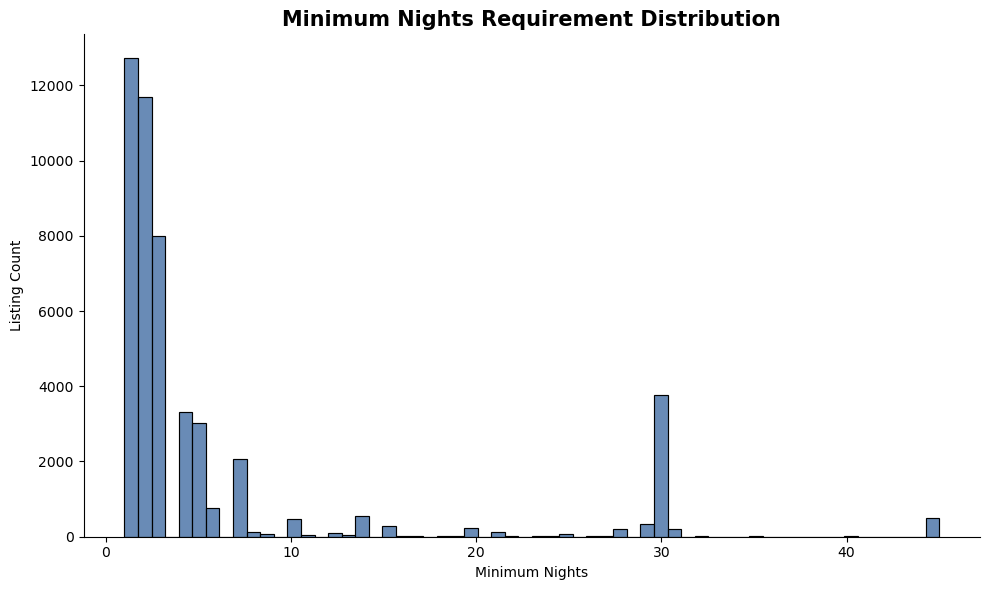

In [112]:
plt.figure(figsize=(10,6))

sns.histplot(
    minimum_nights_distribution,
    bins=60,
    color=sns.color_palette("mako")[2]
)

plt.title("Minimum Nights Requirement Distribution", fontsize=15, weight="bold")
plt.xlabel("Minimum Nights")
plt.ylabel("Listing Count")

sns.despine()
plt.tight_layout()
plt.show()

Most bookings are made for stays between 1 and 5 nights, which reflects a typical short-term rental pattern. In particular, 1–2 night stays represent the largest share of bookings.

However, there is also a notable increase in bookings for 30-night stays, which is an interesting pattern and may indicate the presence of longer-term rental behavior within the dataset. This trend could be worth further investigation to understand whether it reflects monthly stays, discounts for extended bookings, or regulatory effects on short-term rentals

Q10 --Geographic Distribution of Listings by Neighborhood Group

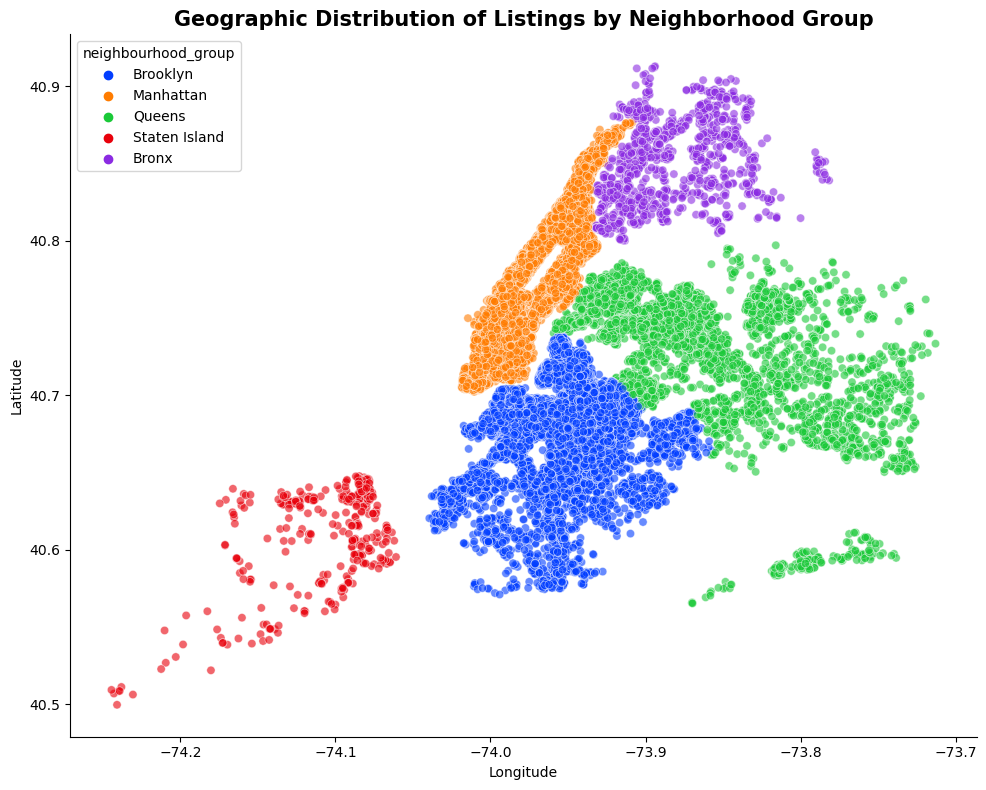

In [113]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=data,
    x='longitude',
    y='latitude',
    hue='neighbourhood_group',
    alpha=0.6,
    palette = 'bright'
)

plt.title("Geographic Distribution of Listings by Neighborhood Group", fontsize=15, weight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

sns.despine()
plt.tight_layout()
plt.show()

Q11 --Geographic Distribution of Listings by Room Type 

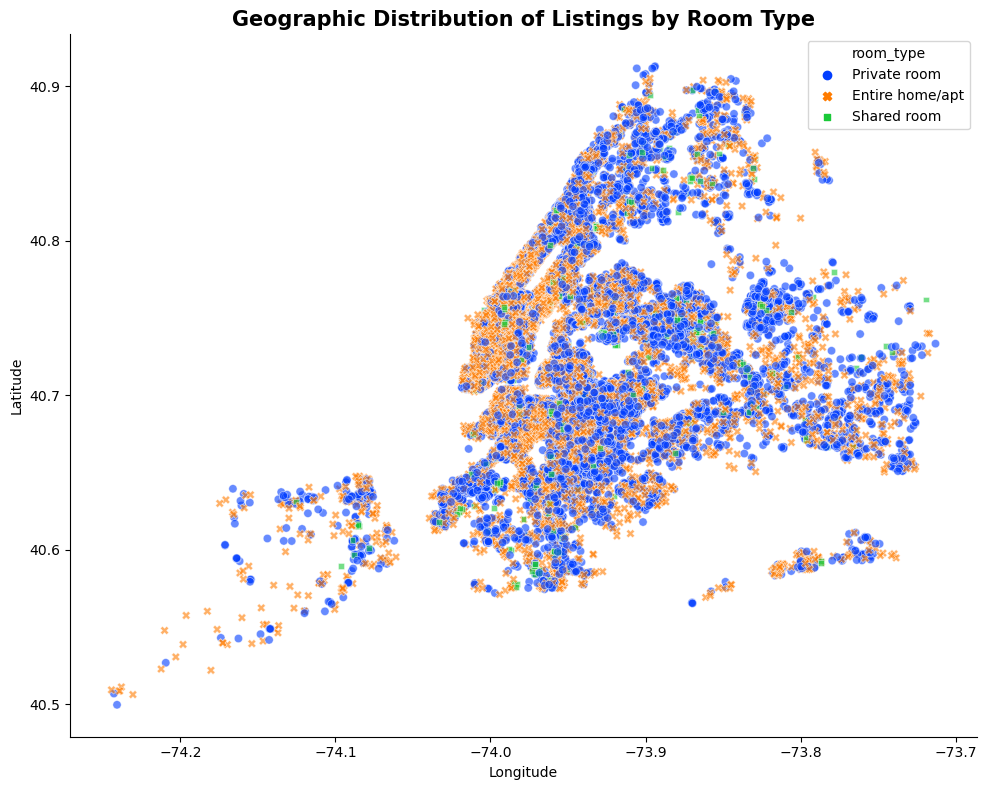

In [114]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=data,
    x='longitude',
    y='latitude',
    hue='room_type',
    style='room_type',
    alpha=0.6,
    palette = 'bright'
)

plt.title("Geographic Distribution of Listings by Room Type", fontsize=15, weight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

sns.despine()
plt.tight_layout()
plt.show()

Q12 --Geographic Distribution of Listings by Room Type & Neighborhood Group

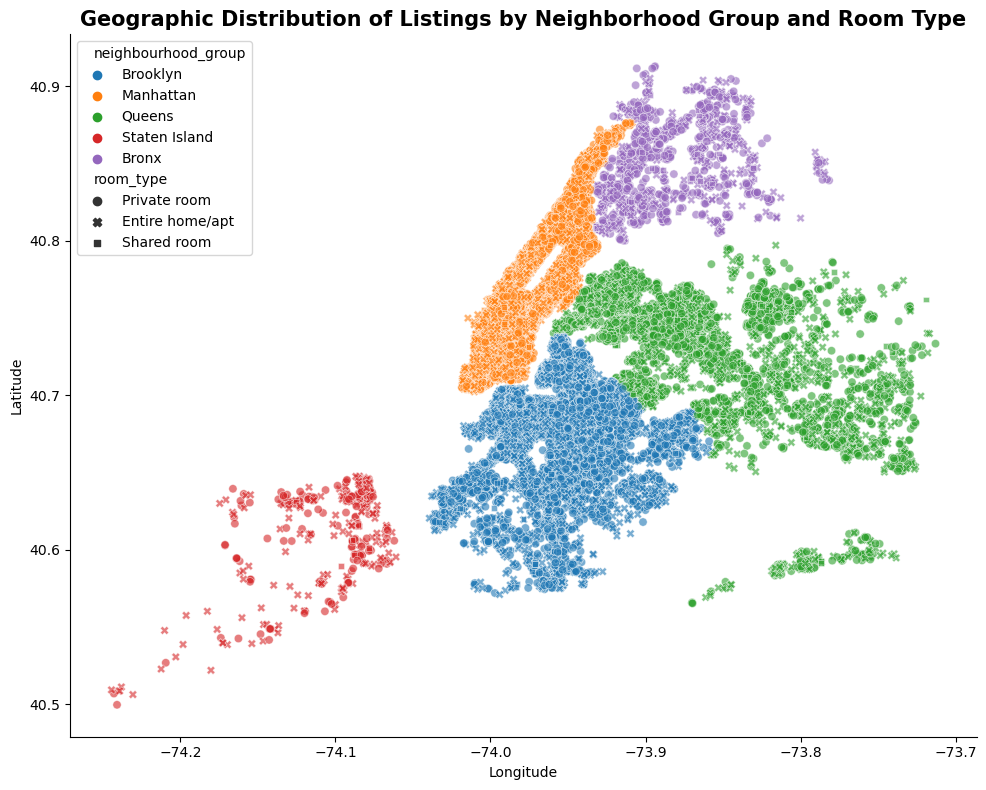

In [115]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=data,
    x='longitude',
    y='latitude',
    hue='neighbourhood_group',
    style='room_type',
    alpha=0.6
)

plt.title("Geographic Distribution of Listings by Neighborhood Group and Room Type", fontsize=15, weight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

sns.despine()
plt.tight_layout()
plt.show()

### insights summary

Airbnb listings across New York City are primarily concentrated in Manhattan and Brooklyn, which together dominate the overall supply of apartments. This pattern is expected given Manhattan’s strong tourism importance and its role as the economic and cultural center of the city.

Manhattan shows the largest diversity in pricing, ranging from low-cost listings to high-end luxury apartments. In particular, Manhattan contains the highest number of premium listings, but it also includes some lower-priced options, suggesting a highly competitive and segmented market.

Brooklyn represents a balanced alternative market, offering relatively more affordable neighborhoods while still benefiting from proximity to Manhattan. This makes Brooklyn especially attractive for guests seeking better price–location trade-offs.

Across the platform, entire-home listings are the dominant property type, followed by private rooms, while shared rooms are almost nonexistent. This indicates that most guests prefer privacy and full-property stays.

In terms of pricing levels across boroughs:

Manhattan has the highest average listing price
Bronx and Queens show moderate price levels
Staten Island contain the lowest average prices

Finally, listing types appear well distributed across neighborhoods, indicating that different accommodation options are available throughout the city rather than being restricted to specific areas. Overall, the NYC Airbnb market shows strong geographic concentration, clear pricing hierarchy between boroughs, and dominance of entire-home inventory.

### Future Improvements & Enhancements

There is a lot of room for improvement, starting with checking which neighborhoods perform best in each area, and extending to adding data about museums, airports, proximity between neighborhoods, and crime rates.